# Setup

In [14]:
import mne
from mne.preprocessing import ICA, annotate_amplitude
from mne_icalabel import label_components

import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path

In [54]:
mne.viz.set_browser_backend("qt") # pip install pyqt5 mne-qt-browser
mne.set_log_level("INFO")

In [55]:
RESAMPLE_FREQ = 250.0
L_FREQ, H_FREQ = 0.1, 30.0
NOTCH_FREQ = 60.0

MASTOIDS = ["M1", "M2"]

REWP_CHAN = "FCz"
REWP_TMIN, REWP_TMAX = 0.240, 0.340
EPOCH_TMIN, EPOCH_TMAX = -0.200, 0.600
BASELINE = (-0.200, 0.0)

# Rejection thresholds (paper)
PTP_THRESH = 150e-6       # peak-to-peak, volts
GRAD_THRESH = 10e-6       # per-sample gradient at 250 Hz, volts
CHAN_REJECT_PROP = 0.10   # channel is "noisy" if >10% epochs rejected
MAX_BAD_CHANS = 3         # exclude participant if >3 noisy channels

ICA_HP = 1.0              # high-pass for ICA fit
ICLABEL_PROB = 0.80 

# from https://github.com/chassall/differentdoors
# analyze_differentdoors_01_bidsify.m
EVENT_ID = {
    "unlearnable/win":   7,
    "unlearnable/loss":  8,
    "learnable/win":    17,
    "learnable/loss":   18,
}

ANNOT_TO_ID = {
    "Stimulus/S  7":  7,
    "Stimulus/S  8":  8,
    "Stimulus/S 17": 17,
    "Stimulus/S 18": 18,
}

# Load data

In [87]:
#PROJECT_PATH = Path(__file__).parent
PROJECT_PATH = Path.cwd()

DATA_DIR = "data"

raw = mne.io.read_raw_brainvision(
    PROJECT_PATH / DATA_DIR / "sub-02" / "eeg" / "sub-02_task-differentdoors_eeg.vhdr",
    preload = True
)

raw_original = raw.copy()

Extracting parameters from /home/nebu/code/py/uni/projekt-dane-eeg/data/sub-02/eeg/sub-02_task-differentdoors_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 1243759  =      0.000 ...  1243.759 secs...


In [88]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x55f00d0644c0) at 0x7f499377e240>

In [64]:
# reset
#raw = raw_original.copy()

# Filter, resample, reference

In [65]:
raw.filter(
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    method="fir",
    phase="zero",
    fir_design="firwin",
    verbose=False
)

#raw.notch_filter(NOTCH_FREQ, verbose=False)

raw.resample(
    sfreq=RESAMPLE_FREQ,
    npad="auto"
)

raw.add_reference_channels(["Fz"])
raw.set_eeg_reference(
    ref_channels=MASTOIDS,
    verbose=False
)

raw.drop_channels(MASTOIDS)

raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, F3, F7, FC5, FC1, FCz, C3, T7, CP5, CP1, Pz, P3, P7, O1, ...
 chs: 31 EEG
 custom_ref_applied: True
 highpass: 0.1 Hz
 lowpass: 30.0 Hz
 meas_date: 2025-03-31 12:01:00 UTC
 nchan: 31
 projs: []
 sfreq: 250.0 Hz
>

### Set montage

In [68]:
raw.set_montage(
    "easycap-M1",
    match_case=False,
    on_missing="warn"
);

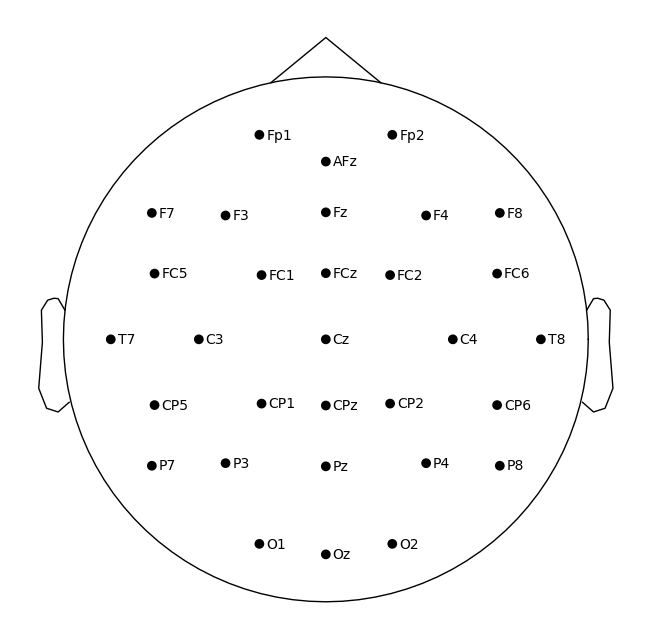

In [69]:
raw.plot_sensors(show_names=True);

### PSD

/home/nebu/miniconda3/envs/mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


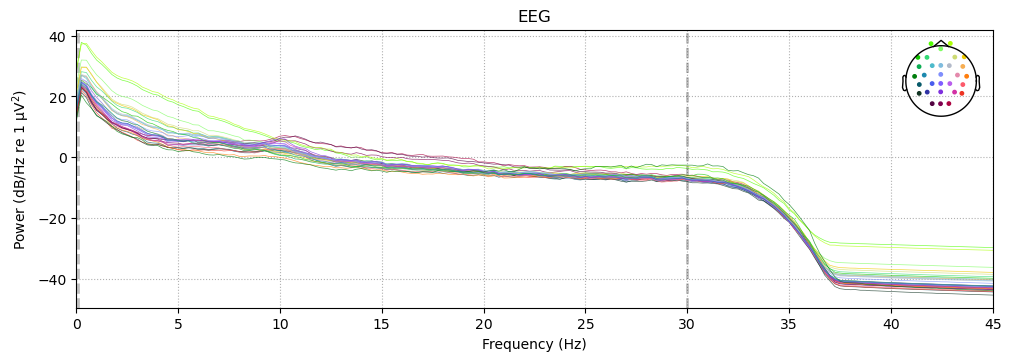

In [27]:
spectrum = raw.compute_psd(
    method="welch",
    n_fft=int(4 * raw.info["sfreq"]),
    fmin=0,
    fmax=H_FREQ*1.5 # force Qt
)

picks_no_fz = [channel for channel in raw.ch_names if channel != "Fz"]
spectrum.plot(
    average=False,
    spatial_colors=True,
    picks=picks_no_fz
)

# Data rank

In [70]:
n_channels = len(raw.ch_names) - len(raw.info["bads"])

automatic_rank = mne.compute_rank(raw, rank="info")['eeg']

print(f"n_channels (w tym Fz): {n_channels}")
print(f"Automatic rank: {automatic_rank}")

# MNE nie loguje utraty rangi na skutek refowania (?), więc:
real_rank = automatic_rank - 1 # Fz reference
print(f"Real rank: {real_rank}")

Computing rank from data with rank='info'
    EEG: rank 31 after 0 projectors applied to 31 channels
n_channels (w tym Fz): 31
Automatic rank: 31
Real rank: 30


# ICA

In [71]:
raw_ica = raw.copy().filter(
    l_freq=ICA_HP,
    h_freq=None,
    verbose=False
)

annot_bad, _ = annotate_amplitude(
    raw_ica,
    peak=1000e-6,   # reject where peak-to-peak > 1000 microvolts
    bad_percent=50  # if >50% of channel is bad drop the channel
)

raw_ica.set_annotations(raw_ica.annotations + annot_bad)

Finding segments below or above PTP threshold.


<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 31 x 399920 (1599.7 s), ~94.6 MiB, data loaded>

In [72]:
annot_bad

<Annotations | 0 segments>

In [73]:
ica = ICA(
    n_components=real_rank,
    method="infomax",
    fit_params=dict(extended=True),
    random_state=97,
    max_iter="auto"
)
ica.fit(raw_ica, reject_by_annotation=True)

Fitting ICA to data using 31 channels (please be patient, this may take a while)
Selecting by number: 30 components
Computing Extended Infomax ICA
Fitting ICA took 162.2s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (399920 samples)
ICA components,30
Available PCA components,31
Channel types,eeg
ICA components marked for exclusion,—


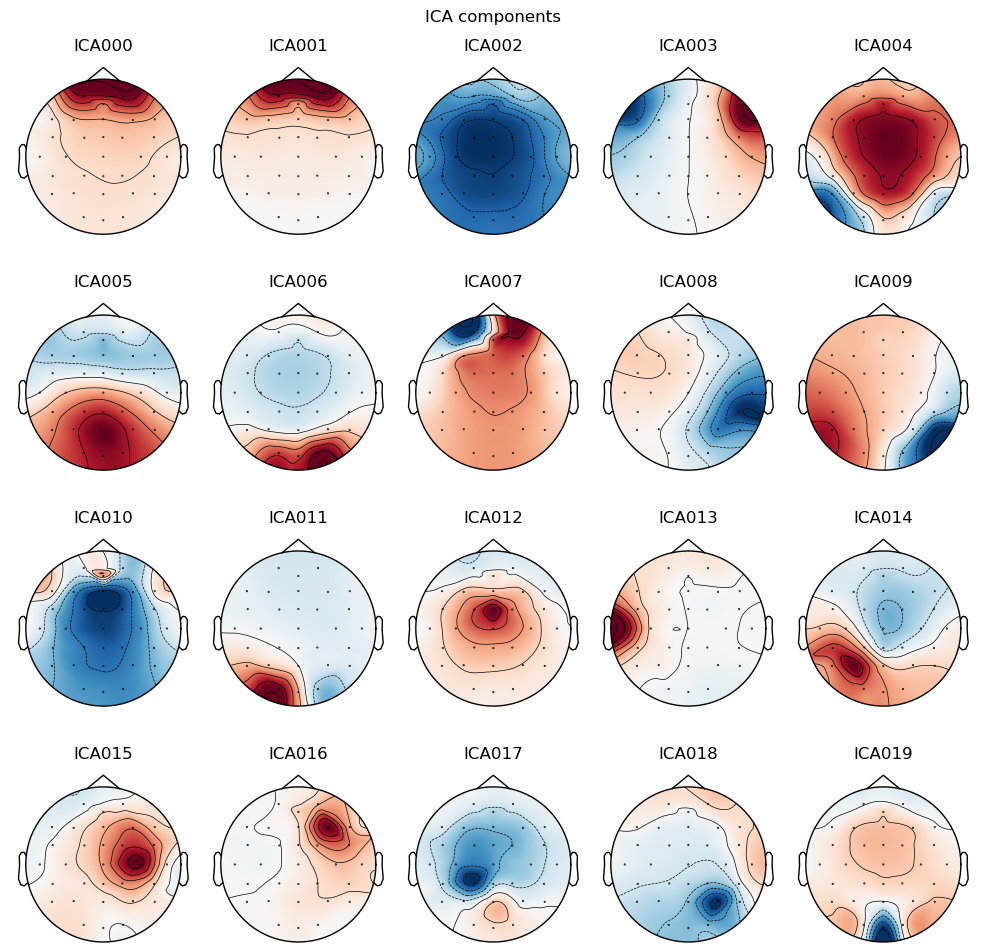

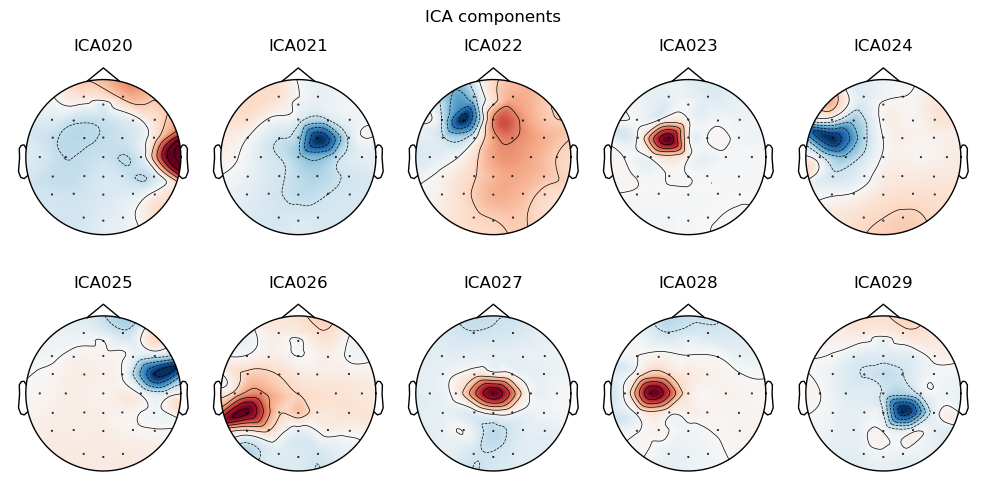

In [75]:
ica.plot_components();

In [76]:
labels = label_components(raw_ica, ica, method="iclabel")
exclude_idx = [
    i for i, (lab, prob) in enumerate(
        zip(labels["labels"], labels["y_pred_proba"]))
    if lab in ("eye blink", "muscle artifact") and prob > ICLABEL_PROB
]
ica.exclude = exclude_idx
ica.apply(raw)
print(f"ICA: removed {len(exclude_idx)} components")

/tmp/ipykernel_1763751/1940085339.py:1: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  labels = label_components(raw_ica, ica, method="iclabel")


Applying ICA to Raw instance
    Transforming to ICA space (30 components)
    Zeroing out 3 ICA components
    Projecting back using 31 PCA components
ICA: removed 3 components


In [77]:
exclude_idx

[0, 1, 3]

In [53]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x55b82e70bec0) at 0x7f9e02609a40>

In [78]:
events, _ = mne.events_from_annotations(raw, event_id=ANNOT_TO_ID, verbose=False)

epochs = mne.Epochs(raw, events, event_id=EVENT_ID,
                    tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, baseline=BASELINE,
                    preload=True, reject=None, verbose=False)

In [79]:
data = epochs.get_data()                          # (n_ep, n_ch, n_t)
ptp = data.max(axis=2) - data.min(axis=2)         # (n_ep, n_ch)
grad = np.abs(np.diff(data, axis=2)).max(axis=2)  # (n_ep, n_ch)
bad_mask = (ptp > PTP_THRESH) | (grad > GRAD_THRESH)

chan_bad_prop = bad_mask.mean(axis=0)
noisy_chans = [epochs.ch_names[i]
               for i, p in enumerate(chan_bad_prop)
               if p > CHAN_REJECT_PROP and epochs.ch_names[i] not in MASTOIDS]

if len(noisy_chans) > MAX_BAD_CHANS:
    raise RuntimeError(
        f"sub-{SUBJECT} excluded: {len(noisy_chans)} noisy channels "
        f"(>{MAX_BAD_CHANS}).")

good_ch_idx = [i for i, ch in enumerate(epochs.ch_names)
               if ch not in noisy_chans]
drop_epoch = bad_mask[:, good_ch_idx].any(axis=1)
epochs.drop(np.where(drop_epoch)[0], reason="artifact", verbose=False)

epochs.info["bads"] = noisy_chans
epochs.interpolate_bads(reset_bads=True, verbose=False)

print(f"Noisy channels interpolated: {noisy_chans}")
print(f"Epochs dropped: {int(drop_epoch.sum())} / {len(drop_epoch)}")


Noisy channels interpolated: []
Epochs dropped: 7 / 396


/tmp/ipykernel_1763751/2441130725.py:22: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs.interpolate_bads(reset_bads=True, verbose=False)


In [80]:
evokeds = {}
for cond in ("learnable", "unlearnable"):
    win = epochs[f"{cond}/win"].average()
    loss = epochs[f"{cond}/loss"].average()
    diff = mne.combine_evoked([win, loss], weights=[1, -1])
    evokeds[cond] = dict(win=win, loss=loss, diff=diff)


def mean_amp_uv(evk):
    """Mean amplitude at REWP_CHAN over the RewP window, in µV."""
    return (evk.copy().pick(REWP_CHAN)
            .crop(REWP_TMIN, REWP_TMAX).data.mean() * 1e6)


rewp_learn = mean_amp_uv(evokeds["learnable"]["diff"])
rewp_unlearn = mean_amp_uv(evokeds["unlearnable"]["diff"])
delta_rewp = rewp_learn - rewp_unlearn

print(f"RewP (learnable):   {rewp_learn:+.2f} µV")
print(f"RewP (unlearnable): {rewp_unlearn:+.2f} µV")
print(f"ΔRewP:              {delta_rewp:+.2f} µV")

RewP (learnable):   +2.89 µV
RewP (unlearnable): +3.51 µV
ΔRewP:              -0.62 µV


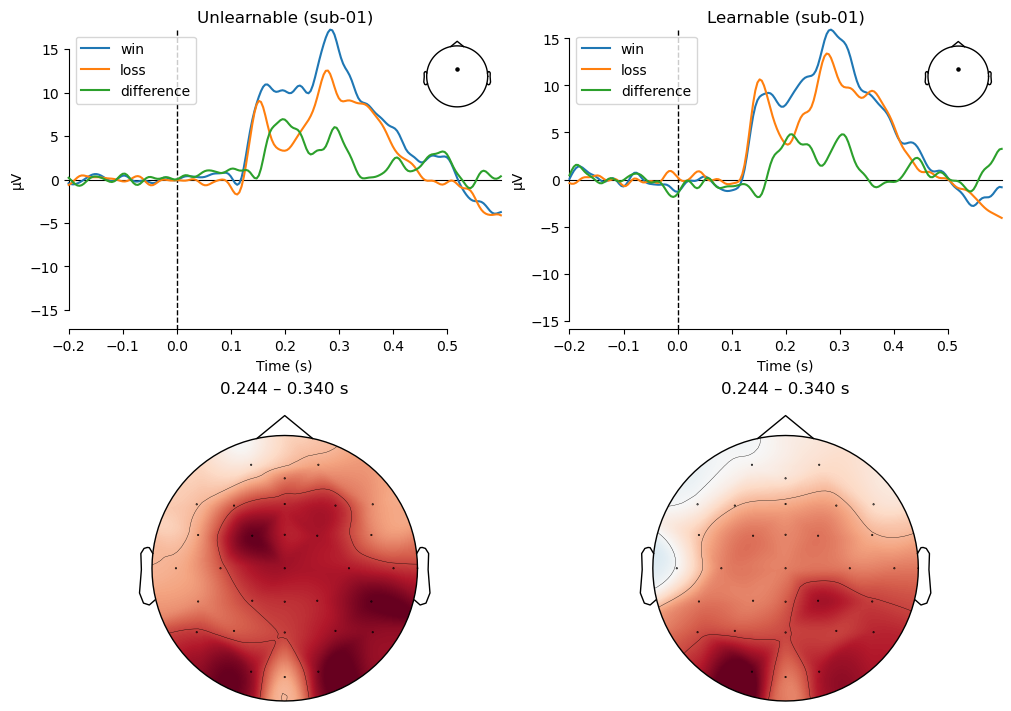

In [85]:
SUBJECT="01"
fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
for j, cond in enumerate(("unlearnable", "learnable")):
    mne.viz.plot_compare_evokeds(
        {"win": evokeds[cond]["win"],
         "loss": evokeds[cond]["loss"],
         "difference": evokeds[cond]["diff"]},
        picks=REWP_CHAN, axes=axes[0, j], show=False,
        title=f"{cond.capitalize()} (sub-{SUBJECT})")
    evokeds[cond]["diff"].plot_topomap(
        times=[(REWP_TMIN + REWP_TMAX) / 2],
        average=REWP_TMAX - REWP_TMIN,
        axes=axes[1, j], show=False, colorbar=False)

#fig.savefig(subj_deriv / f"sub-{SUBJECT}_rewp_diagnostic.png", dpi=200)
plt.show();